# IMPORT DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv')

# Cek data
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## TRAFFIC IMPACT

### DATA CLEANING


In [3]:
print("Rows awal:", len(df))

Rows awal: 45593


In [4]:
print(df['Road_traffic_density'].head())
print(df['Time_taken(min)'].head())

0      High 
1       Jam 
2       Low 
3    Medium 
4      High 
Name: Road_traffic_density, dtype: object
0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: object


In [5]:
# Menghitung jumlah data yang kosong (NaN) di kolom tertentu

df[['Road_traffic_density','Time_taken(min)']].isna().sum()

,0
Road_traffic_density,0
Time_taken(min),0


In [6]:
# membersihkan kategori, menyamakan format, memastikan missing value terdeteksi dengan benar

df['Road_traffic_density'] = df['Road_traffic_density'].astype(str).str.strip()
df['Road_traffic_density'] = df['Road_traffic_density'].replace(
    ['NaN', 'nan', '', ' '], np.nan
)

In [7]:
# Drop null

print("Before:", len(df))

df = df.dropna(subset=['Road_traffic_density','Time_taken(min)'])

print("After:", len(df))

Before: 45593
After: 44992


In [8]:
print(df['Road_traffic_density'].unique())

['High' 'Jam' 'Low' 'Medium']


In [9]:
# Pastikan kolom string
df['Time_taken(min)'] = df['Time_taken(min)'].astype(str)

# Hapus semua selain angka
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace(r'\D', '', regex=True)

# Convert ke numeric
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'], errors='coerce')

# Cek hasil
print(df['Time_taken(min)'].head())
print(df['Time_taken(min)'].dtype)

0    24
1    33
2    26
3    21
4    30
Name: Time_taken(min), dtype: int64
int64


### ANALYSIS DATA TRAFFIC IMPACT

In [10]:
# Grouping by mean traffic density

traffic_avg = df.groupby('Road_traffic_density')['Time_taken(min)'].mean().reset_index()

print(traffic_avg)

  Road_traffic_density  Time_taken(min)
0                 High        27.240000
1                  Jam        31.176624
2                  Low        21.266977
3               Medium        26.699644


/tmp/ipykernel_5384/1327386816.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


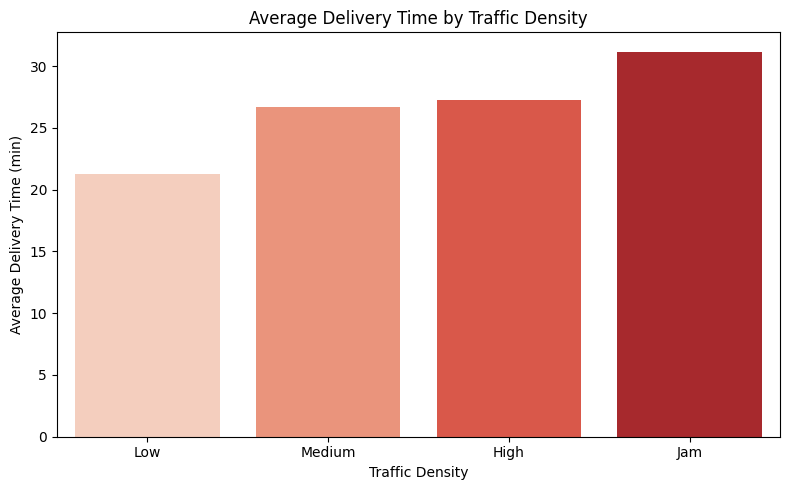

In [11]:
# Bar Chart
order = ['Low','Medium','High','Jam']

plt.figure(figsize=(8,5))

sns.barplot(
    data=traffic_avg,
    x='Road_traffic_density',
    y='Time_taken(min)',
    order=order,
    palette='Reds'
)

plt.title('Average Delivery Time by Traffic Density')
plt.xlabel('Traffic Density')
plt.ylabel('Average Delivery Time (min)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5384/1314793174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


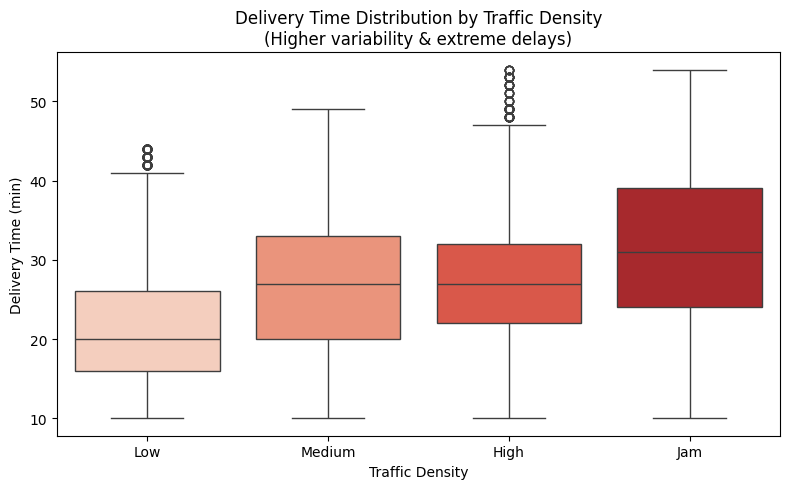

In [12]:
# Boxplot

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Road_traffic_density',
    y='Time_taken(min)',
    order=order,
    palette='Reds'
)

plt.title('Delivery Time Distribution by Traffic Density\n(Higher variability & extreme delays)')
plt.xlabel('Traffic Density')
plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

In [13]:
# Impact

low = traffic_avg[traffic_avg['Road_traffic_density']=='Low']['Time_taken(min)'].values[0]
high = traffic_avg[traffic_avg['Road_traffic_density']=='High']['Time_taken(min)'].values[0]

increase_pct = ((high - low) / low) * 100

print(f"Increase from Low to High: {increase_pct:.2f}%")

Increase from Low to High: 28.09%


## WEATHER IMPACT

### DATA CLEANING

In [14]:
# Clean weather column
df['Weatherconditions'] = df['Weatherconditions'].astype(str).str.strip()

# Handle invalid values
df['Weatherconditions'] = df['Weatherconditions'].replace(
    ['NaN','nan','', ' '], np.nan
)

# Drop null
df = df.dropna(subset=['Weatherconditions','Time_taken(min)'])

In [15]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '')

In [16]:
 print(df['Weatherconditions'].unique())

['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' 'NaN']


In [17]:
print(df['Weatherconditions'].head())

0         Sunny
1        Stormy
2    Sandstorms
3         Sunny
4        Cloudy
Name: Weatherconditions, dtype: object


### ANALYSIS WEATHER CONDITIONS IMPACT

In [18]:
#Grouping by Weather conditions

weather_avg = df.groupby('Weatherconditions')['Time_taken(min)'].mean().reset_index()

# Sort biar rapi (opsional)
weather_avg = weather_avg.sort_values(by='Time_taken(min)', ascending=False)

print(weather_avg)

  Weatherconditions  Time_taken(min)
0            Cloudy        28.917330
1               Fog        28.916122
2               NaN        26.666667
6             Windy        26.118836
3        Sandstorms        25.875517
4            Stormy        25.870815
5             Sunny        21.856947


/tmp/ipykernel_5384/394122333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


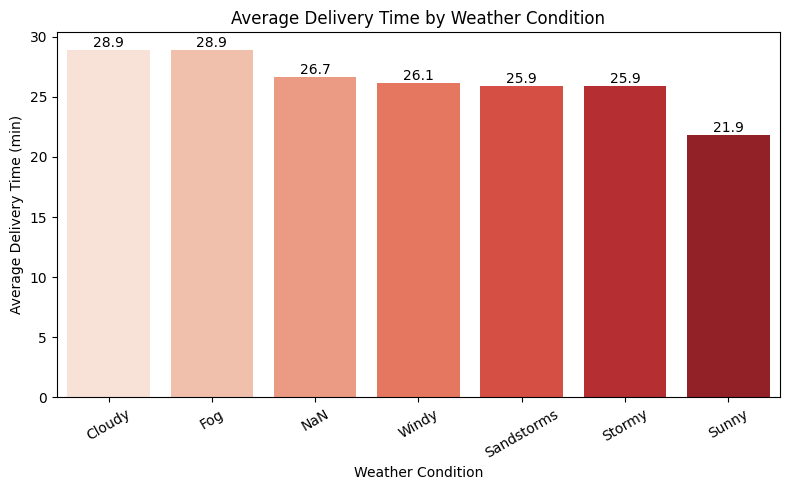

In [19]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=weather_avg,
    x='Weatherconditions',
    y='Time_taken(min)',
    palette='Reds'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Average Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Delivery Time (min)')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5384/3458054816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


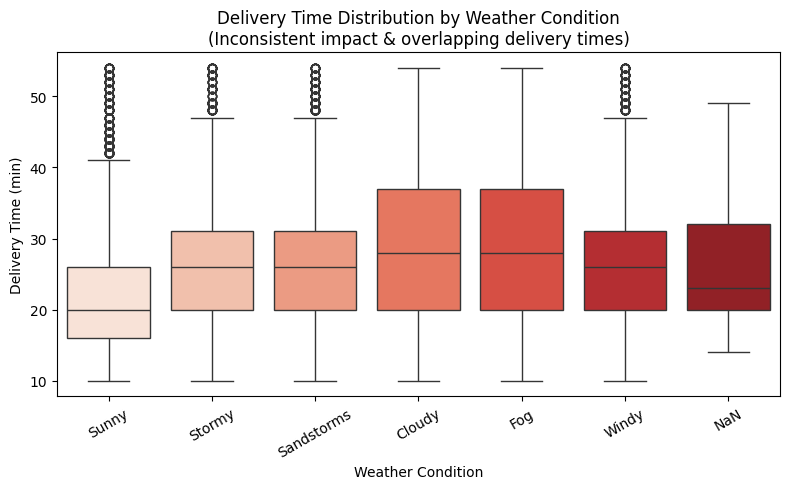

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Weatherconditions',
    y='Time_taken(min)',
    palette='Reds'
)

plt.title('Delivery Time Distribution by Weather Condition\n(Inconsistent impact & overlapping delivery times)')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (min)')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [21]:
# Kondisi tercepat dan terlama

best = weather_avg.loc[weather_avg['Time_taken(min)'].idxmin()]
worst = weather_avg.loc[weather_avg['Time_taken(min)'].idxmax()]

print("Best:", best)
print("Worst:", worst)

Best: Weatherconditions        Sunny
Time_taken(min)      21.856947
Name: 5, dtype: object
Worst: Weatherconditions      Cloudy
Time_taken(min)      28.91733
Name: 0, dtype: object


In [22]:
#Hitung Impact weather

impact_pct = ((worst['Time_taken(min)'] - best['Time_taken(min)']) / best['Time_taken(min)']) * 100

print(f"Weather impact: {impact_pct:.2f}%")

Weather impact: 32.30%


## DRIVER PERFORMANCE

### DATA CLEANING

In [23]:
# Pastikan numeric
df['Delivery_person_Ratings'] = pd.to_numeric(
    df['Delivery_person_Ratings'], errors='coerce'
)

# Drop null
df = df.dropna(subset=['Delivery_person_Ratings','Time_taken(min)'])

In [24]:
df['Delivery_person_Ratings'].describe()

,Delivery_person_Ratings
count,43594.000000
mean,4.635287
std,0.313827
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


In [25]:
df['rating_category'] = pd.cut(
    df['Delivery_person_Ratings'],
    bins=[0,3,4,5],
    labels=['Low','Medium','High']
)

In [26]:
df[['Delivery_person_Ratings','rating_category']].head(10)

,Delivery_person_Ratings,rating_category
0,4.9,High
1,4.5,High
2,4.4,High
3,4.7,High
4,4.6,High
5,4.8,High
6,4.7,High
7,4.6,High
8,4.8,High
9,4.2,High


### ANALYSIS DRIVER PERFORMANCE

In [27]:
df['rating_category'].value_counts()

,count
rating_category,
High,41188
Medium,2298
Low,108


In [28]:
df['Delivery_person_Ratings'].min()
df['Delivery_person_Ratings'].max()

5.0

In [29]:
rating_avg = df.groupby('rating_category')['Time_taken(min)'].mean().reset_index()

print(rating_avg)

  rating_category  Time_taken(min)
0             Low        37.111111
1          Medium        36.020453
2            High        25.720987


/tmp/ipykernel_5384/1272821663.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_avg = df.groupby('rating_category')['Time_taken(min)'].mean().reset_index()


/tmp/ipykernel_5384/2704250616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


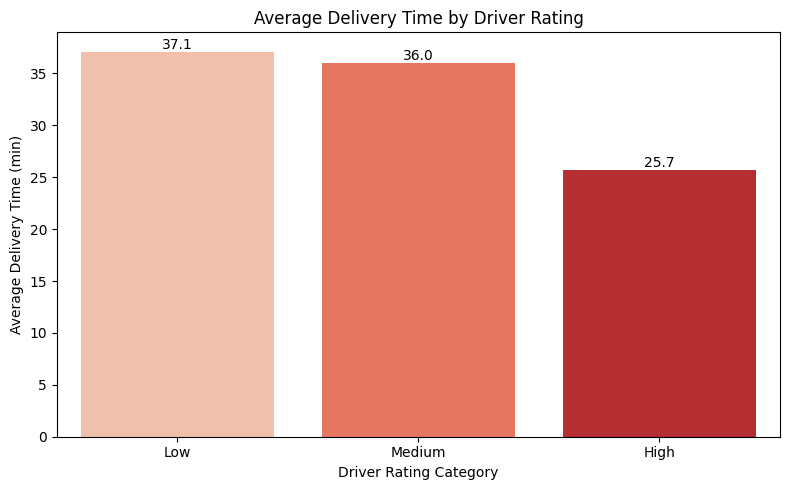

In [30]:
plt.figure(figsize=(8,5))

order = ['Low','Medium','High']

ax = sns.barplot(
    data=rating_avg,
    x='rating_category',
    y='Time_taken(min)',
    order=order,
    palette='Reds'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Average Delivery Time by Driver Rating')
plt.xlabel('Driver Rating Category')
plt.ylabel('Average Delivery Time (min)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5384/1732864617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


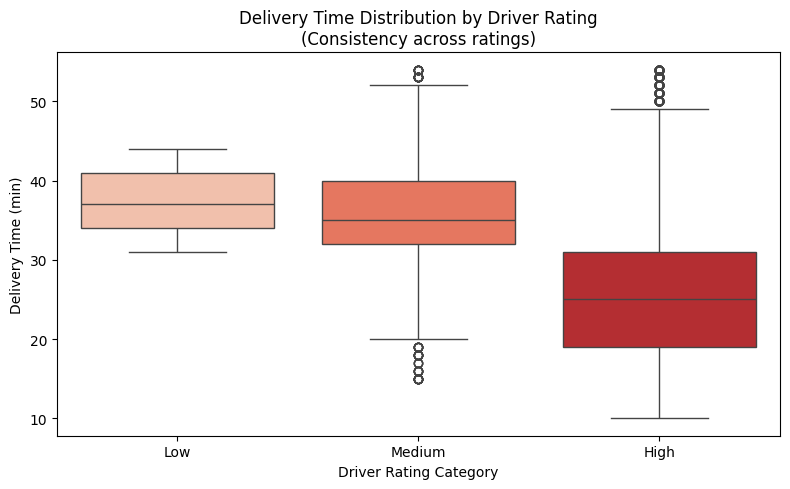

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='rating_category',
    y='Time_taken(min)',
    order=order,
    palette='Reds'
)

plt.title('Delivery Time Distribution by Driver Rating\n(Consistency across ratings)')
plt.xlabel('Driver Rating Category')
plt.ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

In [32]:
low = rating_avg[rating_avg['rating_category']=='Low']['Time_taken(min)'].values[0]
high = rating_avg[rating_avg['rating_category']=='High']['Time_taken(min)'].values[0]

impact_pct = ((low - high) / low) * 100

print(f"Impact rating (Low vs High): {impact_pct:.2f}%")

Impact rating (Low vs High): 30.69%


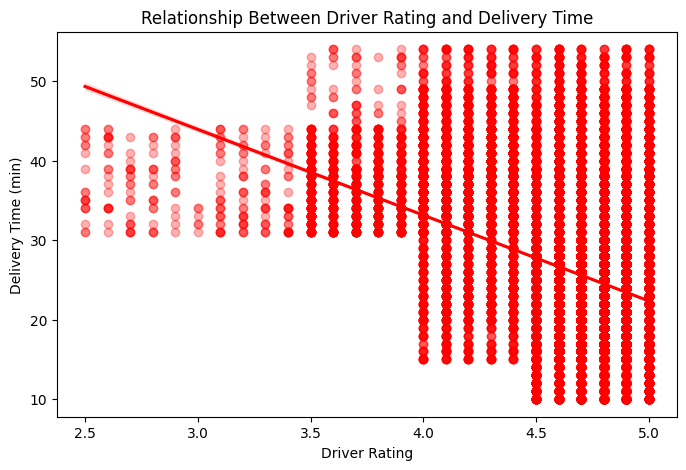

In [35]:
plt.figure(figsize=(8,5))
alpha=0.1

sns.regplot(
    data=df,
    x='Delivery_person_Ratings',
    y='Time_taken(min)',
    scatter_kws={'alpha':0.3, 'color':'red'},
    line_kws={'color':'red'}
)

plt.title('Relationship Between Driver Rating and Delivery Time')
plt.xlabel('Driver Rating')
plt.ylabel('Delivery Time (min)')

plt.show()

## DELIVERY COMPLEXITY

### DATA CLEANING

In [36]:
# Pastikan numeric
df['multiple_deliveries'] = pd.to_numeric(
    df['multiple_deliveries'], errors='coerce'
)

# Drop null
df = df.dropna(subset=['multiple_deliveries','Time_taken(min)'])

In [37]:
df['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1.0,26886
0.0,13524
2.0,1910
3.0,341


### ANALYSIS DELIVERY COMPLEXITY

In [38]:
multi_avg = df.groupby('multiple_deliveries')['Time_taken(min)'].mean().reset_index()

print(multi_avg)

   multiple_deliveries  Time_taken(min)
0                  0.0        22.858548
1                  1.0        26.865357
2                  2.0        40.430890
3                  3.0        47.800587


/tmp/ipykernel_5384/3132164805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


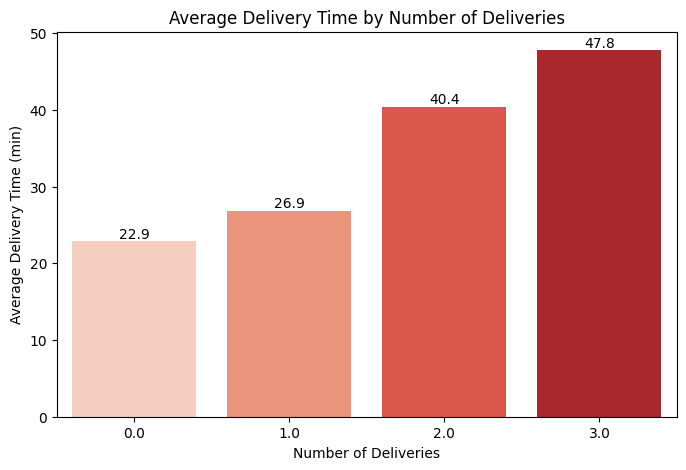

In [39]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=multi_avg,
    x='multiple_deliveries',
    y='Time_taken(min)',
    palette='Reds'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Average Delivery Time by Number of Deliveries')
plt.xlabel('Number of Deliveries')
plt.ylabel('Average Delivery Time (min)')

plt.show()

/tmp/ipykernel_5384/2378617421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


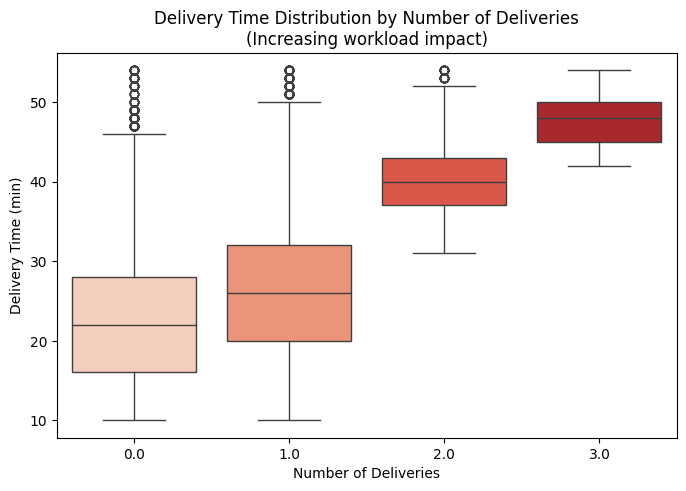

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='multiple_deliveries',
    y='Time_taken(min)',
    palette='Reds'
)

plt.title('Delivery Time Distribution by Number of Deliveries\n(Increasing workload impact)')
plt.xlabel('Number of Deliveries')
plt.ylabel('Delivery Time (min)')

plt.show()

In [41]:
single = multi_avg[multi_avg['multiple_deliveries']==0]['Time_taken(min)'].values[0]
multi = multi_avg[multi_avg['multiple_deliveries']>=1]['Time_taken(min)'].mean()

impact_pct = ((multi - single) / single) * 100

print(f"Impact of multiple deliveries: {impact_pct:.2f}%")

Impact of multiple deliveries: 67.84%


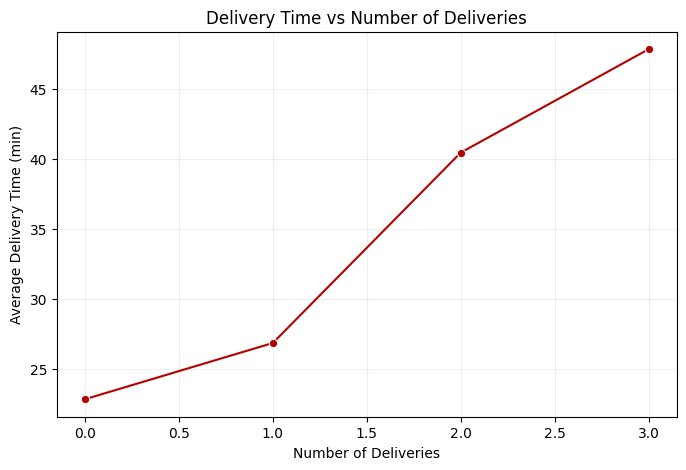

In [42]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=multi_avg,
    x='multiple_deliveries',
    y='Time_taken(min)',
    marker='o',
    color='#b30000'
)

plt.title('Delivery Time vs Number of Deliveries')
plt.xlabel('Number of Deliveries')
plt.ylabel('Average Delivery Time (min)')

plt.grid(alpha=0.2)
plt.show()

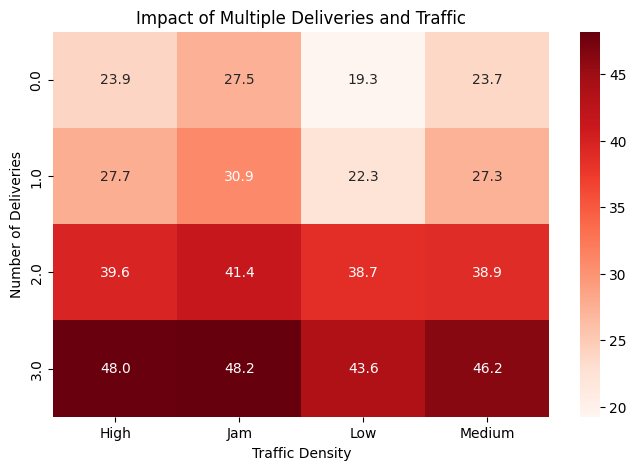

In [43]:
pivot = df.pivot_table(
    values='Time_taken(min)',
    index='multiple_deliveries',
    columns='Road_traffic_density',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Impact of Multiple Deliveries and Traffic')
plt.xlabel('Traffic Density')
plt.ylabel('Number of Deliveries')

plt.show()

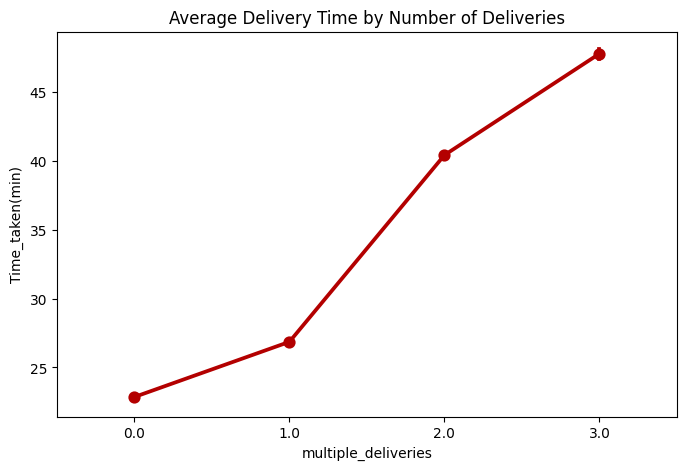

In [44]:
plt.figure(figsize=(8,5))

sns.pointplot(
    data=df,
    x='multiple_deliveries',
    y='Time_taken(min)',
    color='#b30000'
)

plt.title('Average Delivery Time by Number of Deliveries')
plt.show()

## DISTANCE & LOCATION

### DATA CLEANING

In [45]:
import numpy as np

# Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(
    df['Restaurant_latitude'],
    df['Restaurant_longitude'],
    df['Delivery_location_latitude'],
    df['Delivery_location_longitude']
)

In [46]:
df['distance_km'].describe()

,distance_km
count,42661.000000
mean,26.846384
std,299.719518
min,1.465067
25%,4.663456
50%,9.220582
75%,13.682505
max,6884.726399


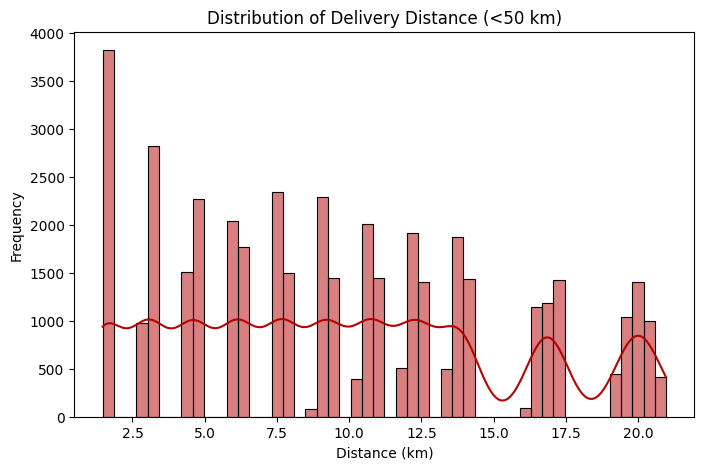

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    df[df['distance_km'] < 50]['distance_km'],
    bins=50,
    kde=True,
    color='#b30000'
)

plt.title('Distribution of Delivery Distance (<50 km)')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')

plt.show()

In [59]:
df['distance_category'] = pd.cut(
    df['distance_km'],
    bins=[0,2,5,10,20],
    labels=['Very Near','Near','Medium','Far']
)

/tmp/ipykernel_5384/3123901174.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_avg = df.groupby('distance_category')['Time_taken(min)'].mean().reset_index()
/tmp/ipykernel_5384/3123901174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


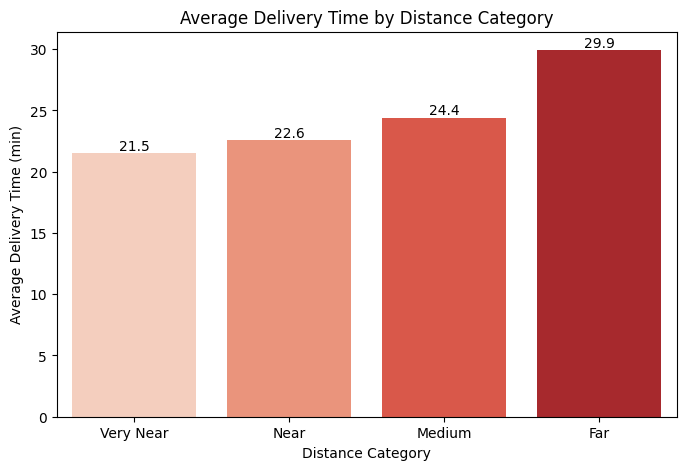

In [60]:
dist_avg = df.groupby('distance_category')['Time_taken(min)'].mean().reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=dist_avg,
    x='distance_category',
    y='Time_taken(min)',
    palette='Reds'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Average Delivery Time by Distance Category')
plt.xlabel('Distance Category')
plt.ylabel('Average Delivery Time (min)')

plt.show()

/tmp/ipykernel_5384/2469677526.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Axes: title={'center': 'Impact of Distance and Traffic on Delivery Time'}, xlabel='Road_traffic_density', ylabel='distance_category'>

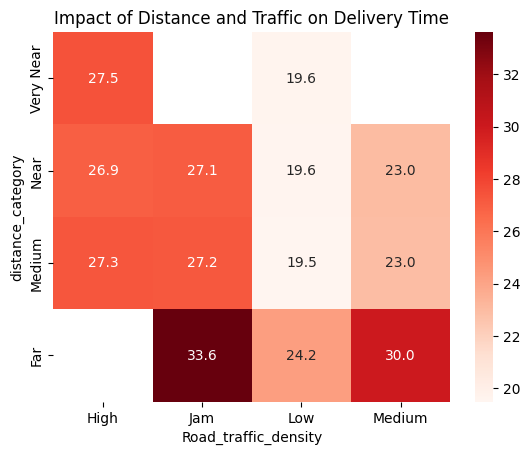

In [69]:
pivot = df.pivot_table(
    values='Time_taken(min)',
    index='distance_category',
    columns='Road_traffic_density',
    aggfunc='mean'
)
plt.title('Impact of Distance and Traffic on Delivery Time')
plt.xlabel('Traffic Density')
plt.ylabel('Distance Category')

sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.1f')

In [62]:
near = dist_avg.iloc[0]['Time_taken(min)']
far = dist_avg.iloc[-1]['Time_taken(min)']

impact_pct = ((far - near) / near) * 100

print(f"Distance impact: {impact_pct:.2f}%")

Distance impact: 39.02%


## EXPORT DATA TO CSV


In [64]:
df.to_csv('cleaned_delivery_data.csv', index=False)

In [65]:
from google.colab import files
files.download('cleaned_delivery_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
import os
print(os.path.exists('cleaned_delivery_data.csv'))

True
